# Khám Phá & Phân Tích Dữ Liệu Tuyển Dụng Tiếng Việt (EDA)
## Exploratory Data Analysis for Vietnamese Job Recommendation Dataset (Kaggle)

Notebook này thực hiện Khám phá và Phân tích Thống kê Dữ liệu (EDA) trên tập dữ liệu tuyển dụng Kaggle thực tế tại `D:\NCKH\paper-2026\data`:
- **`JOB_DATA_FINAL.csv`**: 14,634 tin tuyển dụng doanh nghiệp tại Việt Nam.
- **`USER_DATA_FINAL.csv`**: 3,983 hồ sơ ứng viên (CVs).

Nội dung phân tích bao gồm: Thống kê cơ bản, Phân bố ngành nghề/kỹ năng, Phân tích số năm kinh nghiệm, Phân bố địa lý, và **Khám phá đặc trưng tương quan CV–Job**.

### 1. Khởi Tạo Môi Trường và Tải Dữ Liệu Thực Tế

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display

# Setting publication-quality plot style
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid", palette="muted")

data_dir = 'data'
job_path = os.path.join(data_dir, 'JOB_DATA_FINAL.csv')
user_path = os.path.join(data_dir, 'USER_DATA_FINAL.csv')

df_j = pd.read_csv(job_path)
df_u = pd.read_csv(user_path)

print(f"-> JOB_DATA_FINAL shape : {df_j.shape[0]:,} tin tuyển dụng, {df_j.shape[1]} cột")
print(f"-> USER_DATA_FINAL shape: {df_u.shape[0]:,} hồ sơ ứng viên, {df_u.shape[1]} cột")

-> JOB_DATA_FINAL shape : 14,634 tin tuyển dụng, 19 cột
-> USER_DATA_FINAL shape: 3,983 hồ sơ ứng viên, 14 cột


### 2. Tổng Quan Cấu Trúc & Kiểm Tra Dữ Liệu Khuyết (Missing Values)

In [2]:
print("=== BẢNG KHUYẾT DỮ LIỆU TIN TUYỂN DỤNG (JOB_DATA_FINAL) ===")
job_missing = df_j.isnull().sum().to_frame(name='Missing Count')
job_missing['Missing %'] = (job_missing['Missing Count'] / len(df_j) * 100).round(2)
display(job_missing[job_missing['Missing Count'] > 0])

print("\n=== BẢNG KHUYẾT DỮ LIỆU HỒ SƠ ỨNG VIÊN (USER_DATA_FINAL) ===")
user_missing = df_u.isnull().sum().to_frame(name='Missing Count')
user_missing['Missing %'] = (user_missing['Missing Count'] / len(df_u) * 100).round(2)
display(user_missing[user_missing['Missing Count'] > 0])

=== BẢNG KHUYẾT DỮ LIỆU TIN TUYỂN DỤNG (JOB_DATA_FINAL) ===


,Missing Count,Missing %



=== BẢNG KHUYẾT DỮ LIỆU HỒ SƠ ỨNG VIÊN (USER_DATA_FINAL) ===


,Missing Count,Missing %


### 3. Phân Phối Vị Trí Tuyển Dụng & Ngành Nghề Top Đầu

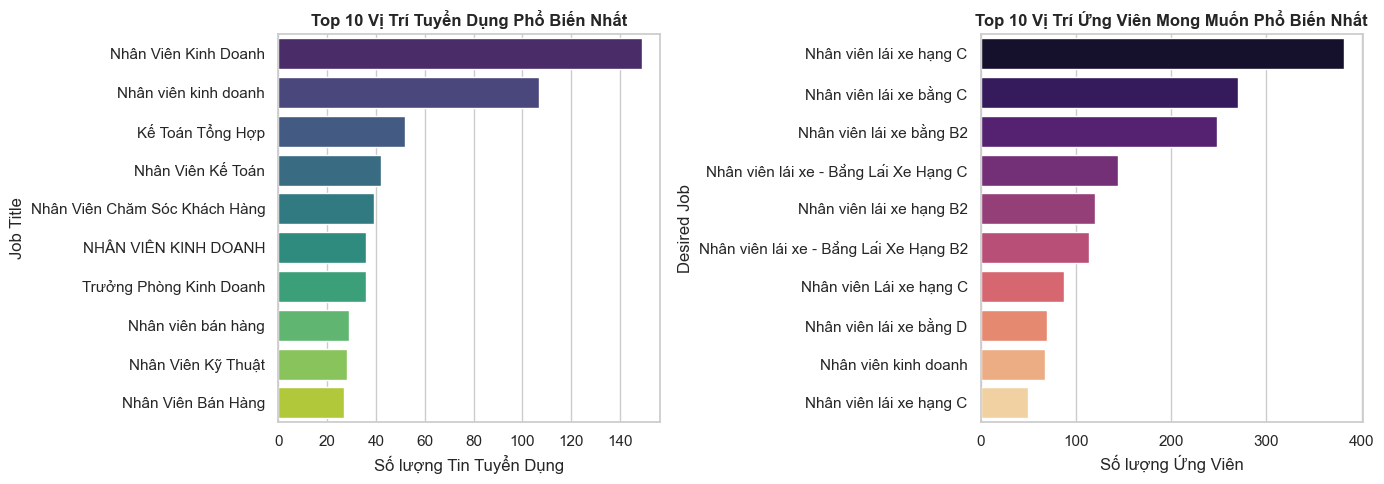

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top Job Titles
top_jobs = df_j['Job Title'].value_counts().head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, ax=axes[0], hue=top_jobs.index, legend=False, palette='viridis')
axes[0].set_title('Top 10 Vị Trí Tuyển Dụng Phổ Biến Nhất', fontweight='bold')
axes[0].set_xlabel('Số lượng Tin Tuyển Dụng')

# Top Desired Jobs (Candidates)
top_user_jobs = df_u['Desired Job'].value_counts().head(10)
sns.barplot(x=top_user_jobs.values, y=top_user_jobs.index, ax=axes[1], hue=top_user_jobs.index, legend=False, palette='magma')
axes[1].set_title('Top 10 Vị Trí Ứng Viên Mong Muốn Phổ Biến Nhất', fontweight='bold')
axes[1].set_xlabel('Số lượng Ứng Viên')

plt.tight_layout()
plt.show()

### 4. Phân Tích Kinh Nghiệm Yêu Cầu vs Kinh Nghiệm Ứng Viên

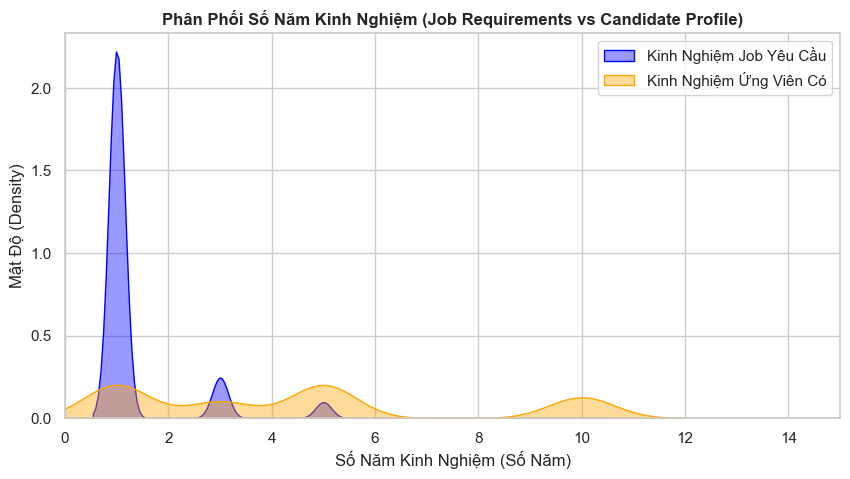

In [4]:
def parse_exp(val):
    if pd.isna(val):
        return np.nan
    nums = re.findall(r'\d+', str(val))
    return float(nums[0]) if nums else np.nan

job_exp = df_j['Years of Experience'].apply(parse_exp).dropna()
user_exp = df_u['Work Experience'].apply(parse_exp).dropna()

plt.figure(figsize=(10, 5))
sns.kdeplot(job_exp, label='Kinh Nghiệm Job Yêu Cầu', fill=True, color='blue', alpha=0.4)
sns.kdeplot(user_exp, label='Kinh Nghiệm Ứng Viên Có', fill=True, color='orange', alpha=0.4)
plt.title('Phân Phối Số Năm Kinh Nghiệm (Job Requirements vs Candidate Profile)', fontweight='bold')
plt.xlabel('Số Năm Kinh Nghiệm (Số Năm)')
plt.ylabel('Mật Độ (Density)')
plt.xlim(0, 15)
plt.legend()
plt.show()

### 5. Phân Tích Phân Bố Kỹ Năng (Skills Word Cloud / Frequency)

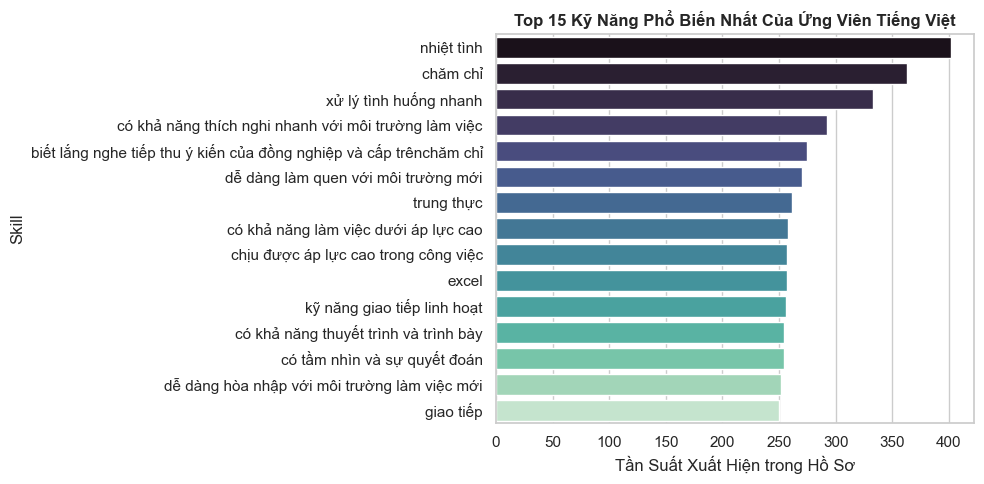

In [5]:
all_skills = []
for s in df_u['Skills'].dropna():
    tokens = re.split(r'[,|/;:\n\-]+', str(s).lower())
    all_skills.extend([t.strip() for t in tokens if len(t.strip()) > 1])

top_skills_counter = Counter(all_skills).most_common(15)
skill_df = pd.DataFrame(top_skills_counter, columns=['Skill', 'Frequency'])

plt.figure(figsize=(10, 5))
sns.barplot(data=skill_df, x='Frequency', y='Skill', hue='Skill', legend=False, palette='mako')
plt.title('Top 15 Kỹ Năng Phổ Biến Nhất Của Ứng Viên Tiếng Việt', fontweight='bold')
plt.xlabel('Tần Suất Xuất Hiện trong Hồ Sơ')
plt.tight_layout()
plt.show()

### 6. Khám Phá Ma Trận Tương Quan Đặc Trưng CV–Job Matching

[DATA LOADER] Found real Kaggle dataset files in 'data'. Processing real dataset...
Loading real Kaggle dataset from 'data'...


Constructed 5600 real candidate-job matching evaluation pairs.
Loaded 5600 constructed matching evaluation pairs.


,loc_match,skill_iou,exp_score,role_match,desc_sem_sim,heuristic_score,gold_relevance
count,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000,5600.000000
mean,0.257143,0.101973,0.965705,0.050819,0.180616,0.321462,0.551071
std,0.437098,0.058489,0.141313,0.092075,0.082918,0.136372,0.498147
min,0.000000,0.000032,0.201897,0.000000,0.000000,0.042140,0.000000
25%,0.000000,0.052258,1.000000,0.000000,0.132179,0.239744,0.000000
50%,0.000000,0.102327,1.000000,0.021325,0.185943,0.258650,1.000000
75%,1.000000,0.151789,1.000000,0.067545,0.235330,0.426832,1.000000
max,1.000000,0.316787,1.000000,1.000000,0.638157,0.672483,2.000000


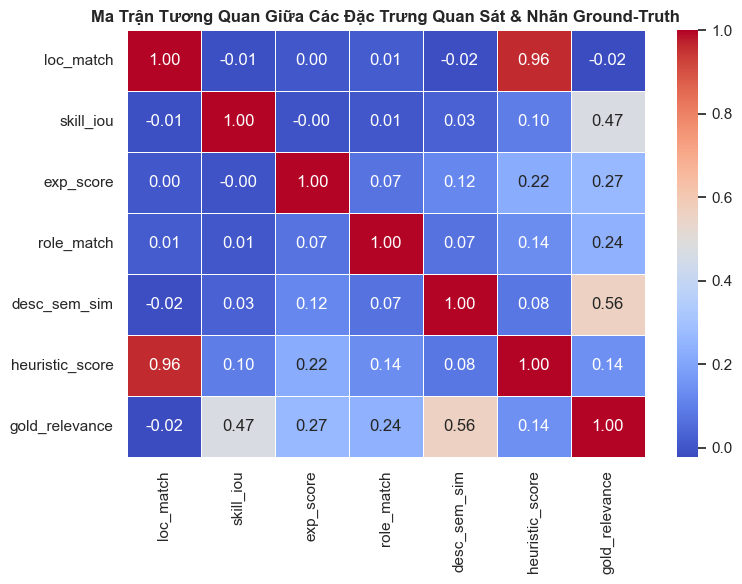

In [6]:
from src.data_loader import load_dataset, FEATURE_COLS

# Load processed candidate-job pairs matrix (5,600 pairs)
df_pairs = load_dataset(data_dir='data', random_seed=42)

print(f"Loaded {len(df_pairs)} constructed matching evaluation pairs.")
display(df_pairs[FEATURE_COLS + ['heuristic_score', 'gold_relevance']].describe())

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_pairs[FEATURE_COLS + ['heuristic_score', 'gold_relevance']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma Trận Tương Quan Giữa Các Đặc Trưng Quan Sát & Nhãn Ground-Truth', fontweight='bold')
plt.tight_layout()
plt.show()